In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [ ]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (200, 5)

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

print(df[numeric_cols].describe())
print("\nMedian:")
print(df[numeric_cols].median())

              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000

Median:
Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64


In [ ]:
gender_count = df["Gender"].value_counts()
gender_ratio = df["Gender"].value_counts(normalize=True) * 100

print("Gender count:")
print(gender_count)

print("\nGender ratio:")
print(gender_ratio)

Gender count:
Gender
Female    112
Male       88
Name: count, dtype: int64

Gender ratio:
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


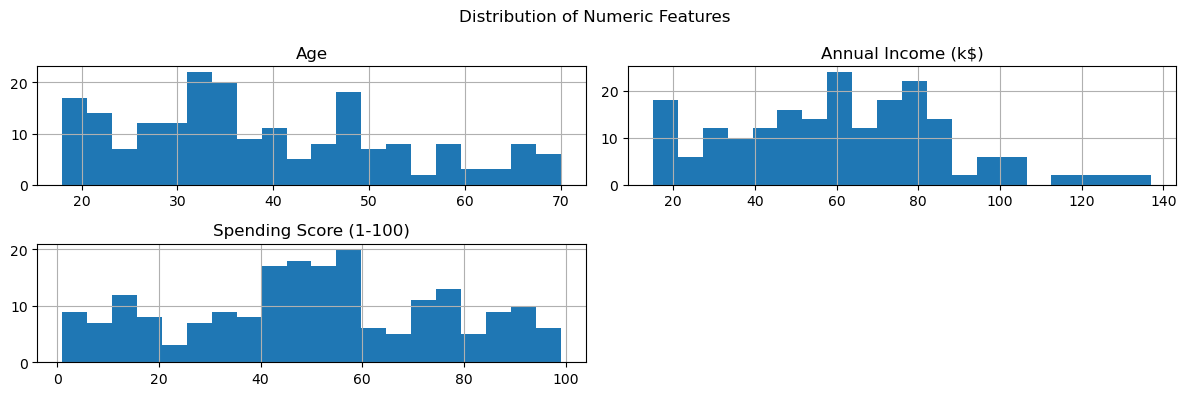

In [ ]:
df[numeric_cols].hist(figsize=(12, 4), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

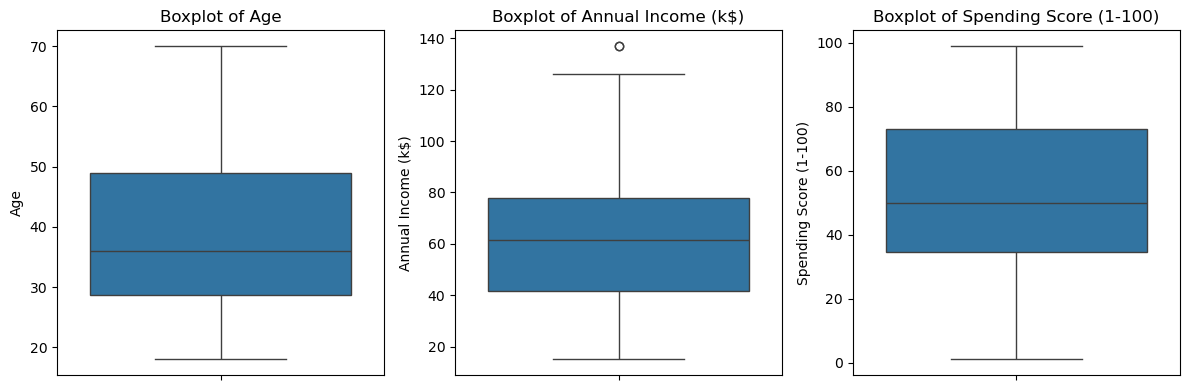

In [ ]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

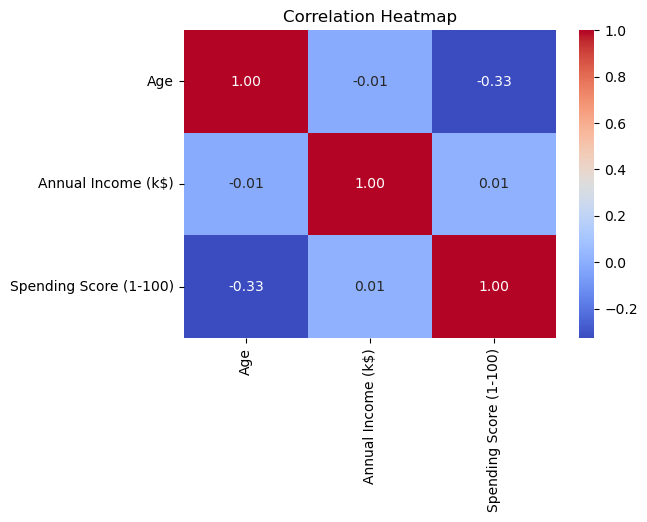

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

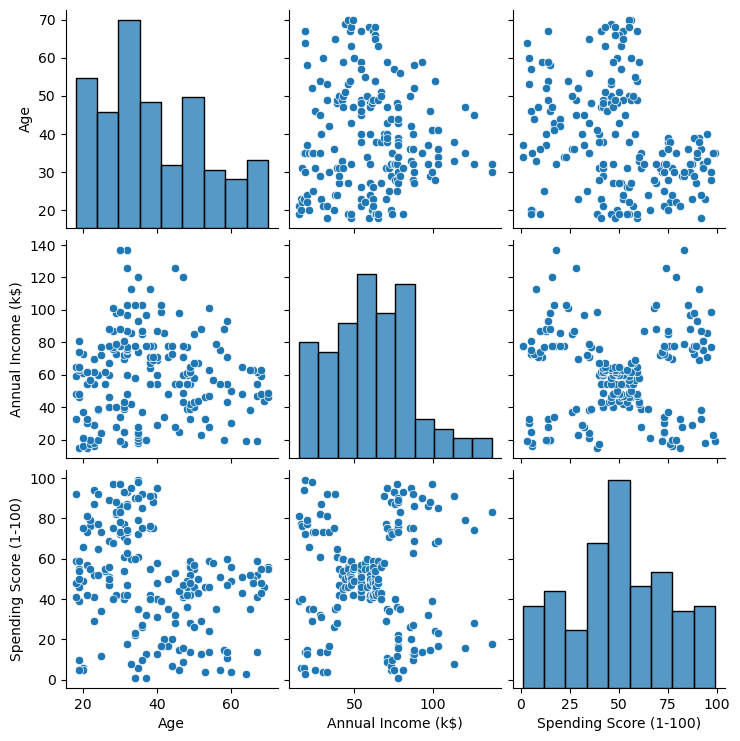

In [ ]:
sns.pairplot(df[numeric_cols])
plt.show()

In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

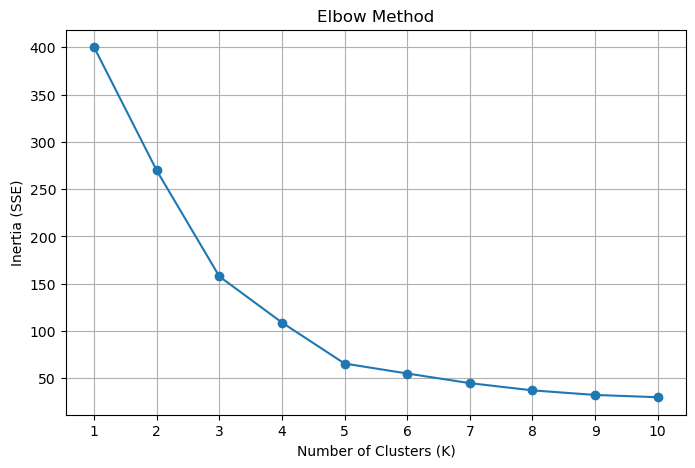

In [ ]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

features = ["Annual Income (k$)", "Spending Score (1-100)"]
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


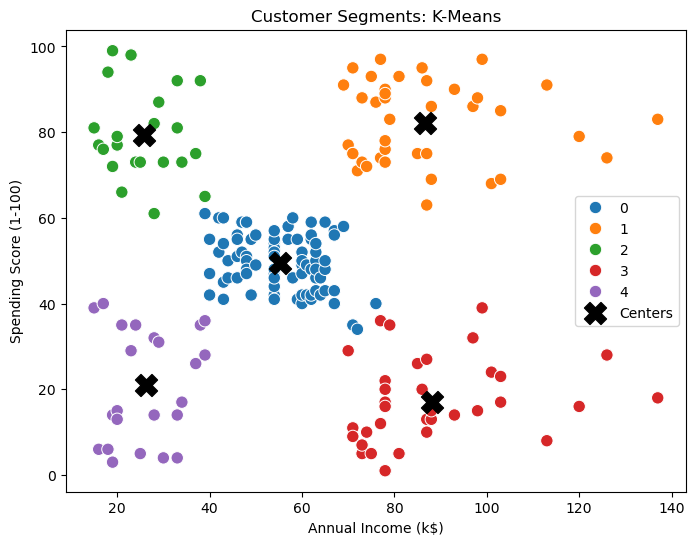

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c="black",
    s=250,
    marker="X",
    label="Centers"
)

plt.title("Customer Segments: K-Means")
plt.legend()
plt.show()

In [ ]:
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(2)
cluster_profile["Count"] = df["Cluster"].value_counts().sort_index()
segment_names = {}

for cluster_id in cluster_profile.index:
    income = cluster_profile.loc[cluster_id, "Annual Income (k$)"]
    score = cluster_profile.loc[cluster_id, "Spending Score (1-100)"]

    if income >= df["Annual Income (k$)"].median() and score >= df["Spending Score (1-100)"].median():
        segment_names[cluster_id] = "Өндөр орлоготой - өндөр хэрэглээтэй"
    elif income >= df["Annual Income (k$)"].median() and score < df["Spending Score (1-100)"].median():
        segment_names[cluster_id] = "Өндөр орлоготой - бага хэрэглээтэй"
    elif income < df["Annual Income (k$)"].median() and score >= df["Spending Score (1-100)"].median():
        segment_names[cluster_id] = "Бага орлоготой - өндөр хэрэглээтэй"
    else:
        segment_names[cluster_id] = "Бага орлоготой - бага хэрэглээтэй"

cluster_profile["Segment Name"] = cluster_profile.index.map(segment_names)
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count,Segment Name
Cluster,,,,,
0,42.72,55.30,49.52,81,Бага орлоготой - бага хэрэглээтэй
1,32.69,86.54,82.13,39,Өндөр орлоготой - өндөр хэрэглээтэй
2,25.27,25.73,79.36,22,Бага орлоготой - өндөр хэрэглээтэй
3,41.11,88.20,17.11,35,Өндөр орлоготой - бага хэрэглээтэй
4,45.22,26.30,20.91,23,Бага орлоготой - бага хэрэглээтэй


In [ ]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(score, 3))
print("Final chosen K =", k)
print("\nCluster Centers:")
print(centers_df)

print("\nCluster Profile:")
print(cluster_profile)

Silhouette Score: 0.555
Final chosen K = 5

Cluster Centers:
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043

Cluster Profile:
           Age  Annual Income (k$)  Spending Score (1-100)  Count  \
Cluster                                                             
0        42.72               55.30                   49.52     81   
1        32.69               86.54                   82.13     39   
2        25.27               25.73                   79.36     22   
3        41.11               88.20                   17.11     35   
4        45.22               26.30                   20.91     23   

                                Segment Name  
Cluster                                       
0          Бага орлоготой - бага хэрэглээтэй  
1        Өндөр орлог

In [ ]:
n_components_range = range(1, 11)
aic_scores = []
bic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

print("AIC:", aic_scores)
print("BIC:", bic_scores)

AIC: [np.float64(1145.1312123220987), np.float64(1117.623164001806), np.float64(1095.6468791100385), np.float64(1027.9288493699294), np.float64(963.0010487892964), np.float64(959.2416988029232), np.float64(952.0975054247747), np.float64(947.3497849478206), np.float64(931.9950051849719), np.float64(933.0174642586618)]
BIC: [np.float64(1161.622799154839), np.float64(1153.9046550338344), np.float64(1151.718274341355), np.float64(1103.790148800534), np.float64(1058.6522524191894), np.float64(1074.6828066321045), np.float64(1087.328517453244), np.float64(1102.3707011755782), np.float64(1106.8058256120178), np.float64(1127.618188884996)]


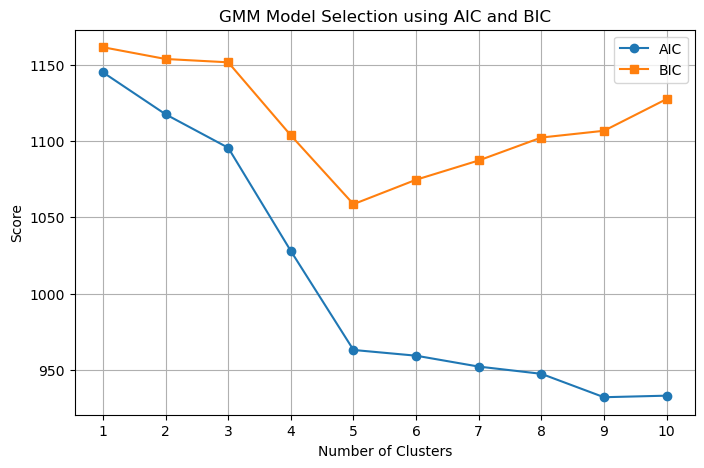

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(n_components_range, aic_scores, marker='o', label='AIC')
plt.plot(n_components_range, bic_scores, marker='s', label='BIC')

plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("GMM Model Selection using AIC and BIC")
plt.xticks(list(n_components_range))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

df["GMM_Cluster"] = labels

print(df[["Annual Income (k$)", "Spending Score (1-100)", "GMM_Cluster"]].head())

   Annual Income (k$)  Spending Score (1-100)  GMM_Cluster
0                  15                      39            4
1                  15                      81            2
2                  16                       6            4
3                  16                      77            2
4                  17                      40            4


In [ ]:
probabilities = gmm.predict_proba(X_scaled)

prob_df = pd.DataFrame(probabilities)
print("Cluster probability (first 5 rows):")
print(prob_df.head())

Cluster probability (first 5 rows):
              0             1             2             3         4
0  1.576897e-05  1.880092e-08  9.520312e-04  5.200131e-08  0.999032
1  1.627762e-05  1.895968e-04  9.997902e-01  4.210134e-23  0.000004
2  2.213394e-19  9.526157e-19  1.225495e-12  1.862233e-04  0.999814
3  1.054448e-04  1.800877e-04  9.996937e-01  3.793901e-21  0.000021
4  6.473014e-05  3.842732e-08  1.556695e-03  4.757227e-08  0.998378


In [ ]:
sil_score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score (GMM): {sil_score:.3f}")

Silhouette Score (GMM): 0.554


In [ ]:
means_scaled = gmm.means_
means_original = scaler.inverse_transform(means_scaled)

centers_df = pd.DataFrame(
    means_original,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

print("GMM Cluster Centers (Original Scale):")
print(centers_df)

GMM Cluster Centers (Original Scale):
   Annual Income (k$)  Spending Score (1-100)
0           55.710354               49.406987
1           86.240633               82.020375
2           25.117486               80.128174
3           88.813008               16.124618
4           27.031152               22.166702


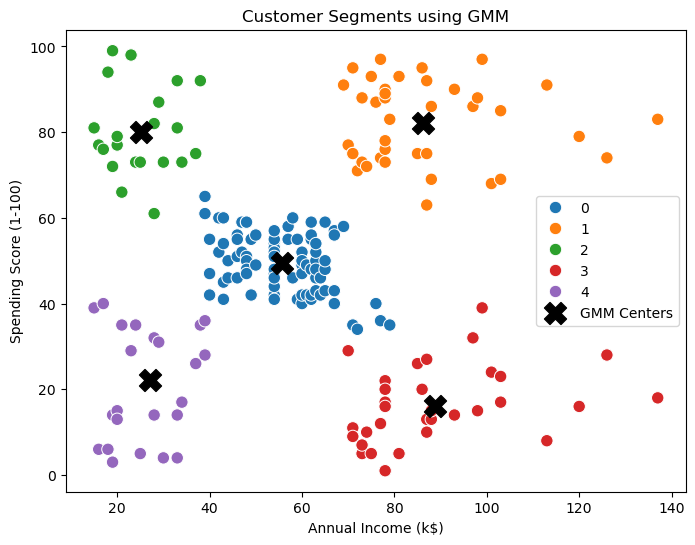

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="GMM_Cluster",
    palette="tab10",
    s=80
)

plt.scatter(
    means_original[:, 0],
    means_original[:, 1],
    c="black",
    s=250,
    marker="X",
    label="GMM Centers"
)

plt.title("Customer Segments using GMM")
plt.legend()
plt.show()

In [ ]:
cluster_profile = df.groupby("GMM_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(2)
cluster_profile["Count"] = df["GMM_Cluster"].value_counts().sort_index()

print(cluster_profile)

               Age  Annual Income (k$)  Spending Score (1-100)  Count
GMM_Cluster                                                          
0            42.71               55.64                   49.37     84
1            32.69               86.54                   82.13     39
2            25.33               25.10                   80.05     21
3            40.45               88.82                   16.00     33
4            45.22               26.30                   20.91     23


In [ ]:
income_median = df["Annual Income (k$)"].median()
score_median = df["Spending Score (1-100)"].median()

segment_names = {}

for cluster_id in cluster_profile.index:
    income = cluster_profile.loc[cluster_id, "Annual Income (k$)"]
    score = cluster_profile.loc[cluster_id, "Spending Score (1-100)"]

    if income >= income_median and score >= score_median:
        segment_names[cluster_id] = "Өндөр орлоготой - өндөр хэрэглээтэй"
    elif income >= income_median and score < score_median:
        segment_names[cluster_id] = "Өндөр орлоготой - бага хэрэглээтэй"
    elif income < income_median and score >= score_median:
        segment_names[cluster_id] = "Бага орлоготой - өндөр хэрэглээтэй"
    else:
        segment_names[cluster_id] = "Бага орлоготой - бага хэрэглээтэй"

cluster_profile["Segment Name"] = cluster_profile.index.map(segment_names)

print(cluster_profile)

               Age  Annual Income (k$)  Spending Score (1-100)  Count  \
GMM_Cluster                                                             
0            42.71               55.64                   49.37     84   
1            32.69               86.54                   82.13     39   
2            25.33               25.10                   80.05     21   
3            40.45               88.82                   16.00     33   
4            45.22               26.30                   20.91     23   

                                    Segment Name  
GMM_Cluster                                       
0              Бага орлоготой - бага хэрэглээтэй  
1            Өндөр орлоготой - өндөр хэрэглээтэй  
2             Бага орлоготой - өндөр хэрэглээтэй  
3             Өндөр орлоготой - бага хэрэглээтэй  
4              Бага орлоготой - бага хэрэглээтэй  


In [ ]:
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count,Segment Name
GMM_Cluster,,,,,
0,42.71,55.64,49.37,84,Бага орлоготой - бага хэрэглээтэй
1,32.69,86.54,82.13,39,Өндөр орлоготой - өндөр хэрэглээтэй
2,25.33,25.10,80.05,21,Бага орлоготой - өндөр хэрэглээтэй
3,40.45,88.82,16.00,33,Өндөр орлоготой - бага хэрэглээтэй
4,45.22,26.30,20.91,23,Бага орлоготой - бага хэрэглээтэй
